---
# 🎓**Hackathon Dados - Projeto de Conclusão de Curso Grupo 9:**


## 🧠 **Objetivo do Projeto:**
O objetivo deste projeto é desenvolver uma solução de ponta a ponta para prever se um solicitante de empréstimo será um bom ou mau pagador integrando dados de consumo e finanças para apoiar decisões de negócios.

A base de dados contém mais de 450.000 registros de empréstimos de 2015, com 74 variáveis originais que descrevem o comportamento financeiro e de crédito dos clientes.

###**Base de Dados:**

Link para download:
https://www.kaggle.com/datasets/somyaagarwal69/loan-data-2015/data

---

###📚 **Sobre o Dataset**
Os dados brutos incluem informações sobre mais de 450.000 empréstimos ao consumidor concedidos no ano de 2015, com quase 75 variáveis, incluindo o status atual do empréstimo e vários atributos relacionados tanto aos tomadores de empréstimo quanto ao seu comportamento de pagamento.



##🔄 Sincronizar com o Drive e Importar as Bibliotecas


In [1]:
#Sincronizar com o drive
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [2]:
#Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#📝 Carregar e Explorar a Base de Dados

In [3]:
df_dataset = pd.read_csv('/content/drive/MyDrive/Projeto Elas+Tech/loan_data_2015.csv')
df_dataset.head(5)

/tmp/ipykernel_47509/2318788235.py:1: DtypeWarning: Columns (19,47,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dataset = pd.read_csv('/content/drive/MyDrive/Projeto Elas+Tech/loan_data_2015.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,60516983,64537751,20000,20000,20000,36 months,12.29,667.06,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,41000,NaN,NaN,NaN
1,60187139,64163931,11000,11000,11000,36 months,12.69,369.00,C,C2,...,NaN,NaN,NaN,NaN,NaN,NaN,13100,NaN,NaN,NaN
2,60356453,64333218,7000,7000,7000,36 months,9.99,225.84,B,B3,...,NaN,NaN,NaN,NaN,NaN,NaN,16300,NaN,NaN,NaN
3,59955769,63900496,10000,10000,10000,36 months,10.99,327.34,B,B4,...,NaN,NaN,NaN,NaN,NaN,NaN,34750,NaN,NaN,NaN
4,58703693,62544456,9550,9550,9550,36 months,19.99,354.87,E,E4,...,NaN,NaN,NaN,NaN,NaN,NaN,14100,NaN,NaN,NaN


💡 Na tabela acima cada linha representa um cliente e cada coluna contém uma característica  (idade, renda, etc.)

#🔍 Análise Exploratória de Dados (EDA)

In [4]:
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421094 entries, 0 to 421093
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           421094 non-null  int64  
 1   member_id                    421094 non-null  int64  
 2   loan_amnt                    421094 non-null  int64  
 3   funded_amnt                  421094 non-null  int64  
 4   funded_amnt_inv              421094 non-null  int64  
 5   term                         421094 non-null  object 
 6   int_rate                     421094 non-null  float64
 7   installment                  421094 non-null  float64
 8   grade                        421094 non-null  object 
 9   sub_grade                    421094 non-null  object 
 10  emp_title                    397220 non-null  object 
 11  emp_length                   397277 non-null  object 
 12  home_ownership               421094 non-null  object 
 13 

💡 O dataset contém 421.094 linhas com registros de empréstimos e 74 colunas com informações do cliente e do empréstimo. Foi identificado colunas com valores nulos e tipos de dados inconsistentes que precisarão ser tratados na etapa de limpeza antes da modelagem.

As colunas estão divididas em:

  - 34 colunas de números decimais (float)
  - 17 colunas de números inteiros (int)
  - 23 colunas de texto (object)

As colunas de texto precisam ser tratadas: algumas são categorias úteis, outras são textos livres que podem ser descartados.


##Estatístiva Descritiva

In [5]:
df_dataset.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,4.210940e+05,4.210940e+05,421094.000000,421094.000000,421094.000000,421094.000000,421094.000000,4.210940e+05,421094.000000,421094.000000,...,21372.000000,18617.000000,21372.000000,21372.000000,21372.000000,21372.000000,4.210940e+05,21372.000000,21372.000000,21372.000000
mean,5.393094e+07,5.759572e+07,15240.255561,15240.255561,15234.125991,12.601731,441.872719,7.696561e+04,19.196014,0.347397,...,36552.811389,71.535317,1.389060,2.975482,5887.979740,60.831939,3.365751e+04,0.943945,1.537058,1.977307
std,9.475416e+06,1.013357e+07,8571.313525,8571.313525,8567.923312,4.317873,244.857549,7.395005e+04,23.504060,0.927696,...,43103.833619,23.022862,1.520129,2.631886,5284.701239,20.013254,3.766386e+04,1.446872,2.723339,2.874067
min,5.670500e+04,7.082500e+04,1000.000000,1000.000000,900.000000,5.320000,30.120000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,-4.000000
25%,4.612481e+07,4.922616e+07,8500.000000,8500.000000,8500.000000,9.170000,263.930000,4.600000e+04,12.590000,0.000000,...,10251.500000,58.600000,0.000000,1.000000,2411.000000,47.700000,1.440000e+04,0.000000,0.000000,0.000000
50%,5.536030e+07,5.895358e+07,14000.000000,14000.000000,14000.000000,12.290000,385.425000,6.500000e+04,18.600000,0.000000,...,24684.500000,74.900000,1.000000,2.000000,4483.000000,61.900000,2.460000e+04,0.000000,0.000000,2.000000
75%,6.186216e+07,6.604582e+07,20000.000000,20000.000000,20000.000000,15.590000,578.790000,9.169125e+04,25.340000,0.000000,...,47858.000000,87.600000,2.000000,4.000000,7771.500000,75.200000,4.167425e+04,1.000000,2.000000,3.000000
max,6.861706e+07,7.354484e+07,35000.000000,35000.000000,35000.000000,28.990000,1445.460000,9.500000e+06,9999.000000,39.000000,...,878459.000000,223.300000,22.000000,43.000000,127305.000000,151.400000,9.999999e+06,17.000000,35.000000,32.000000


In [6]:
# 📚 Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estatísticas de todas as colunas numéricas
desc = df_dataset.describe(include='all').T
desc['missing'] = df_dataset.isnull().sum()
desc['missing_pct'] = (df_dataset.isnull().sum() / len(df_dataset) * 100).round(2)

# Exibir estatísticas principais
print("=" * 70)
print("📊 RELATÓRIO DE ANÁLISE ESTATÍSTICA DESCRITIVA")
print("=" * 70)
print(f"Total de linhas: {df_dataset.shape[0]:,}")
print(f"Total de colunas: {df_dataset.shape[1]}")
print(f"Colunas numéricas: {len(df_dataset.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Colunas categóricas: {len(df_dataset.select_dtypes(include='object').columns)}")
print("=" * 70)

# Mostrar estatísticas completas
display(desc)

📊 RELATÓRIO DE ANÁLISE ESTATÍSTICA DESCRITIVA
Total de linhas: 421,094
Total de colunas: 74
Colunas numéricas: 51
Colunas categóricas: 23


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,missing,missing_pct
id,421094.0,NaN,NaN,NaN,53930940.469183,9475415.892393,56705.0,46124812.25,55360302.0,61862157.5,68617057.0,0,0.00
member_id,421094.0,NaN,NaN,NaN,57595724.753841,10133570.698264,70825.0,49226162.0,58953577.0,66045823.0,73544841.0,0,0.00
loan_amnt,421094.0,NaN,NaN,NaN,15240.255561,8571.313525,1000.0,8500.0,14000.0,20000.0,35000.0,0,0.00
funded_amnt,421094.0,NaN,NaN,NaN,15240.255561,8571.313525,1000.0,8500.0,14000.0,20000.0,35000.0,0,0.00
funded_amnt_inv,421094.0,NaN,NaN,NaN,15234.125991,8567.923312,900.0,8500.0,14000.0,20000.0,35000.0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
all_util,21372.0,NaN,NaN,NaN,60.831939,20.013254,0.0,47.7,61.9,75.2,151.4,399722,94.92
total_rev_hi_lim,421094.0,NaN,NaN,NaN,33657.505156,37663.857988,0.0,14400.0,24600.0,41674.25,9999999.0,0,0.00
inq_fi,21372.0,NaN,NaN,NaN,0.943945,1.446872,0.0,0.0,0.0,1.0,17.0,399722,94.92
total_cu_tl,21372.0,NaN,NaN,NaN,1.537058,2.723339,0.0,0.0,0.0,2.0,35.0,399722,94.92


## Análise Detalhada Coluna por Coluna


📊 ANÁLISE: id
✅ Total de valores: 421,094
⚠️ Valores nulos: 0 (0.00%)
📊 Média: 53,930,940.47
📊 Mediana: 55,360,302.00
📊 Desvio Padrão: 9,475,415.89
📊 Mínimo: 56,705.00
📊 Máximo: 68,617,057.00
📊 Q1 (25%): 46,124,812.25
📊 Q2 (50% / Mediana): 55,360,302.00
📊 Q3 (75%): 61,862,157.50
📊 IQR (Q3-Q1): 15,737,345.25
📊 Limite inferior (outlier): 22,518,794.38
📊 Limite superior (outlier): 85,468,175.38
📊 Assimetria (skewness): -0.42
📊 Curtose: -0.17


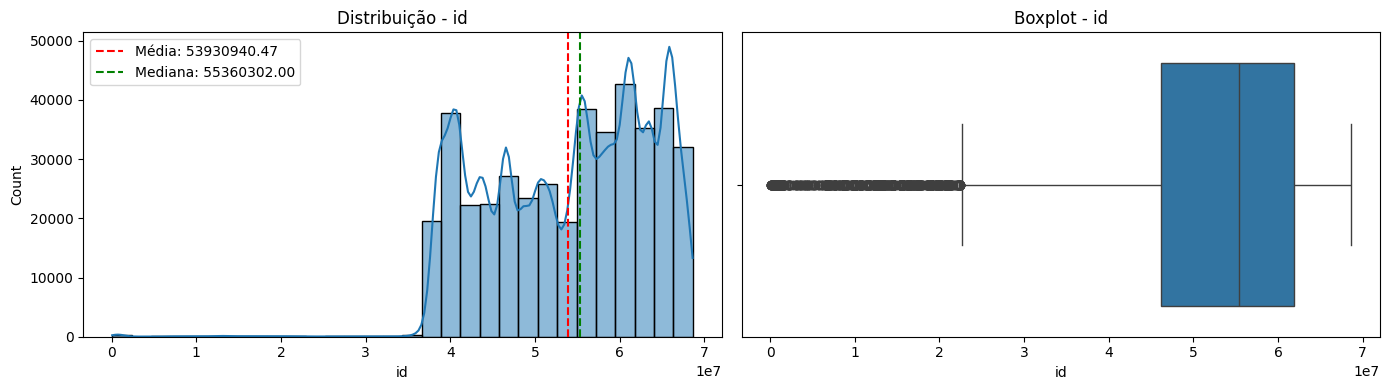


📊 ANÁLISE: member_id
✅ Total de valores: 421,094
⚠️ Valores nulos: 0 (0.00%)
📊 Média: 57,595,724.75
📊 Mediana: 58,953,577.00
📊 Desvio Padrão: 10,133,570.70
📊 Mínimo: 70,825.00
📊 Máximo: 73,544,841.00
📊 Q1 (25%): 49,226,162.00
📊 Q2 (50% / Mediana): 58,953,577.00
📊 Q3 (75%): 66,045,823.00
📊 IQR (Q3-Q1): 16,819,661.00
📊 Limite inferior (outlier): 23,996,670.50
📊 Limite superior (outlier): 91,275,314.50
📊 Assimetria (skewness): -0.40
📊 Curtose: -0.11


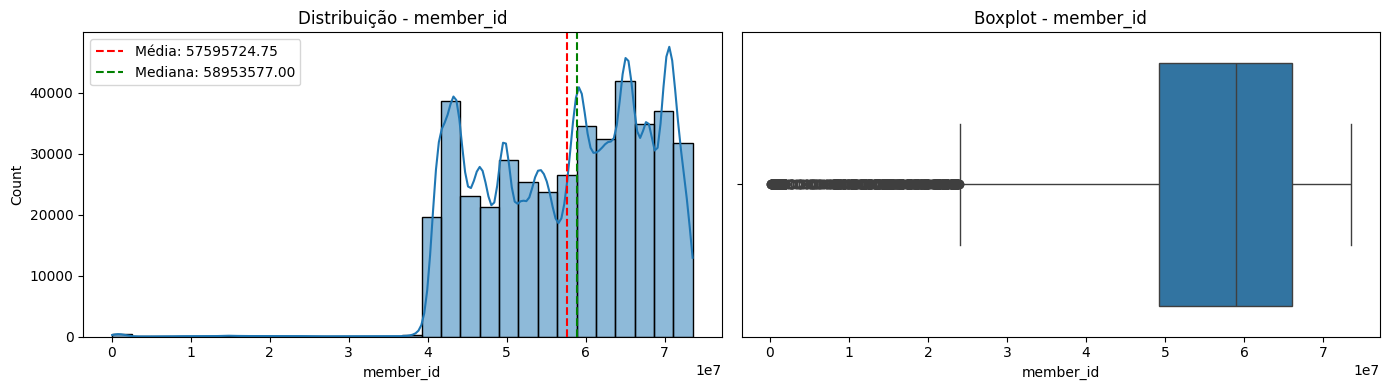


📊 ANÁLISE: loan_amnt
✅ Total de valores: 421,094
⚠️ Valores nulos: 0 (0.00%)
📊 Média: 15,240.26
📊 Mediana: 14,000.00
📊 Desvio Padrão: 8,571.31
📊 Mínimo: 1,000.00
📊 Máximo: 35,000.00
📊 Q1 (25%): 8,500.00
📊 Q2 (50% / Mediana): 14,000.00
📊 Q3 (75%): 20,000.00
📊 IQR (Q3-Q1): 11,500.00
📊 Limite inferior (outlier): -8,750.00
📊 Limite superior (outlier): 37,250.00
📊 Assimetria (skewness): 0.63
📊 Curtose: -0.38


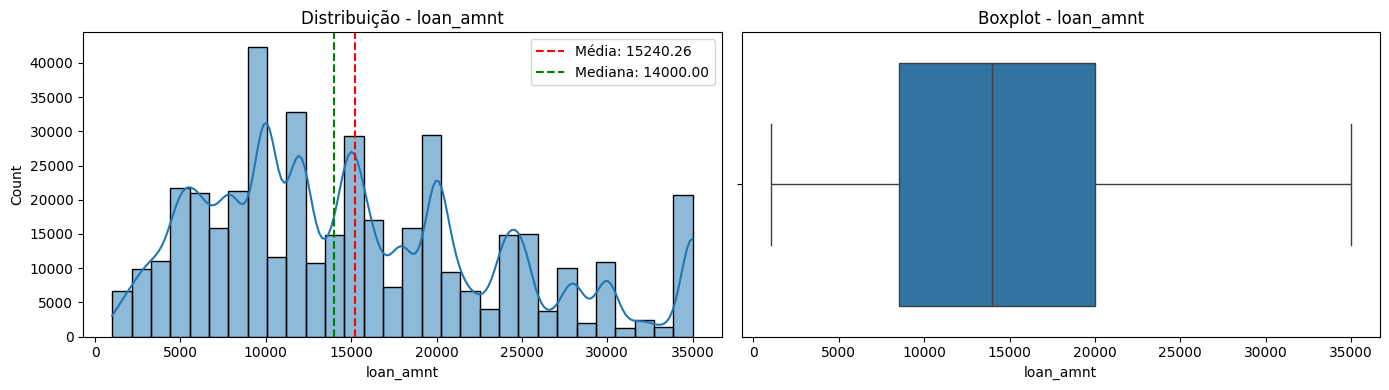


📊 ANÁLISE: funded_amnt
✅ Total de valores: 421,094
⚠️ Valores nulos: 0 (0.00%)
📊 Média: 15,240.26
📊 Mediana: 14,000.00
📊 Desvio Padrão: 8,571.31
📊 Mínimo: 1,000.00
📊 Máximo: 35,000.00
📊 Q1 (25%): 8,500.00
📊 Q2 (50% / Mediana): 14,000.00
📊 Q3 (75%): 20,000.00
📊 IQR (Q3-Q1): 11,500.00
📊 Limite inferior (outlier): -8,750.00
📊 Limite superior (outlier): 37,250.00
📊 Assimetria (skewness): 0.63
📊 Curtose: -0.38


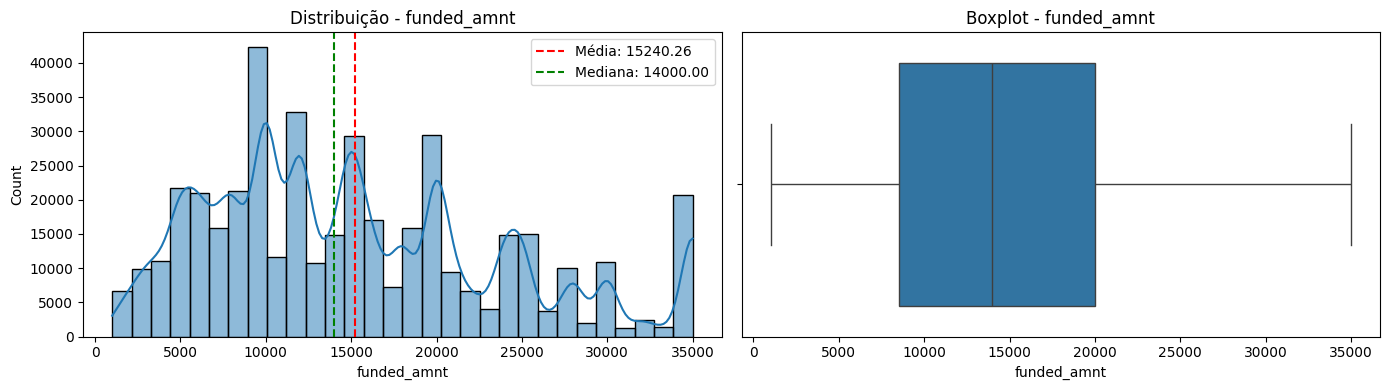


📊 ANÁLISE: funded_amnt_inv
✅ Total de valores: 421,094
⚠️ Valores nulos: 0 (0.00%)
📊 Média: 15,234.13
📊 Mediana: 14,000.00
📊 Desvio Padrão: 8,567.92
📊 Mínimo: 900.00
📊 Máximo: 35,000.00
📊 Q1 (25%): 8,500.00
📊 Q2 (50% / Mediana): 14,000.00
📊 Q3 (75%): 20,000.00
📊 IQR (Q3-Q1): 11,500.00
📊 Limite inferior (outlier): -8,750.00
📊 Limite superior (outlier): 37,250.00
📊 Assimetria (skewness): 0.63
📊 Curtose: -0.38


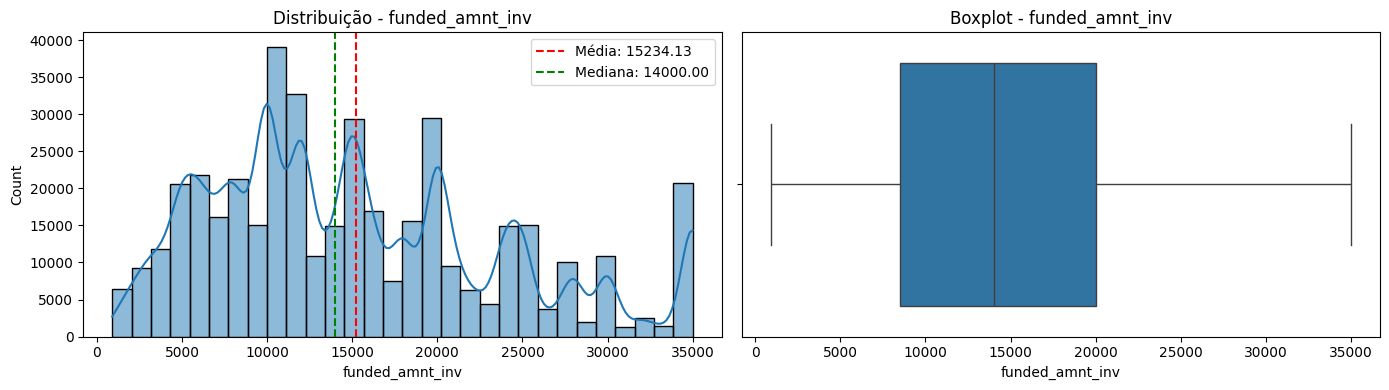


📊 ANÁLISE: int_rate
✅ Total de valores: 421,094
⚠️ Valores nulos: 0 (0.00%)
📊 Média: 12.60
📊 Mediana: 12.29
📊 Desvio Padrão: 4.32
📊 Mínimo: 5.32
📊 Máximo: 28.99
📊 Q1 (25%): 9.17
📊 Q2 (50% / Mediana): 12.29
📊 Q3 (75%): 15.59
📊 IQR (Q3-Q1): 6.42
📊 Limite inferior (outlier): -0.46
📊 Limite superior (outlier): 25.22
📊 Assimetria (skewness): 0.56
📊 Curtose: 0.08


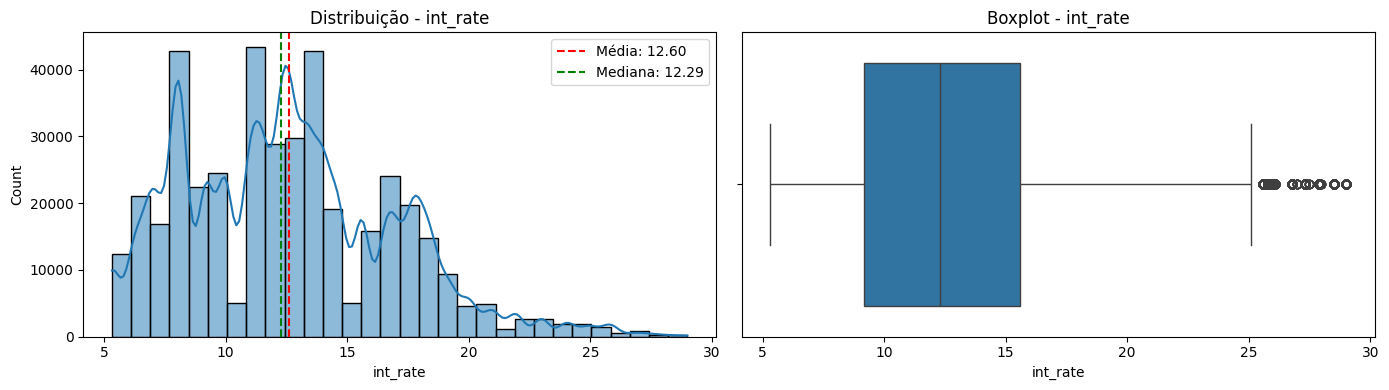


📊 ANÁLISE: installment
✅ Total de valores: 421,094
⚠️ Valores nulos: 0 (0.00%)
📊 Média: 441.87
📊 Mediana: 385.43
📊 Desvio Padrão: 244.86
📊 Mínimo: 30.12
📊 Máximo: 1,445.46
📊 Q1 (25%): 263.93
📊 Q2 (50% / Mediana): 385.43
📊 Q3 (75%): 578.79
📊 IQR (Q3-Q1): 314.86
📊 Limite inferior (outlier): -208.36
📊 Limite superior (outlier): 1,051.08
📊 Assimetria (skewness): 0.92
📊 Curtose: 0.60


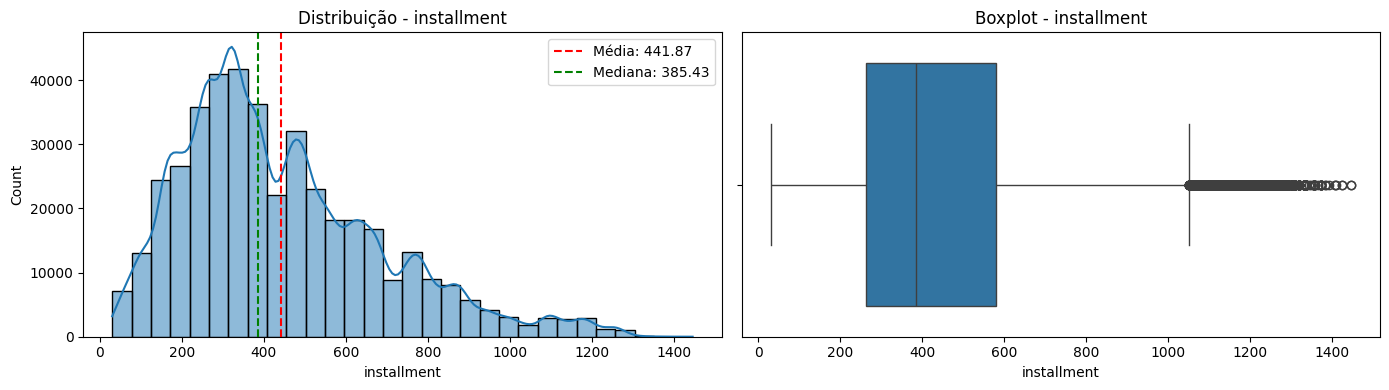


📊 ANÁLISE: annual_inc
✅ Total de valores: 421,094
⚠️ Valores nulos: 0 (0.00%)
📊 Média: 76,965.61
📊 Mediana: 65,000.00
📊 Desvio Padrão: 73,950.05
📊 Mínimo: 0.00
📊 Máximo: 9,500,000.00
📊 Q1 (25%): 46,000.00
📊 Q2 (50% / Mediana): 65,000.00
📊 Q3 (75%): 91,691.25
📊 IQR (Q3-Q1): 45,691.25
📊 Limite inferior (outlier): -22,536.88
📊 Limite superior (outlier): 160,228.12
📊 Assimetria (skewness): 49.29
📊 Curtose: 4894.51


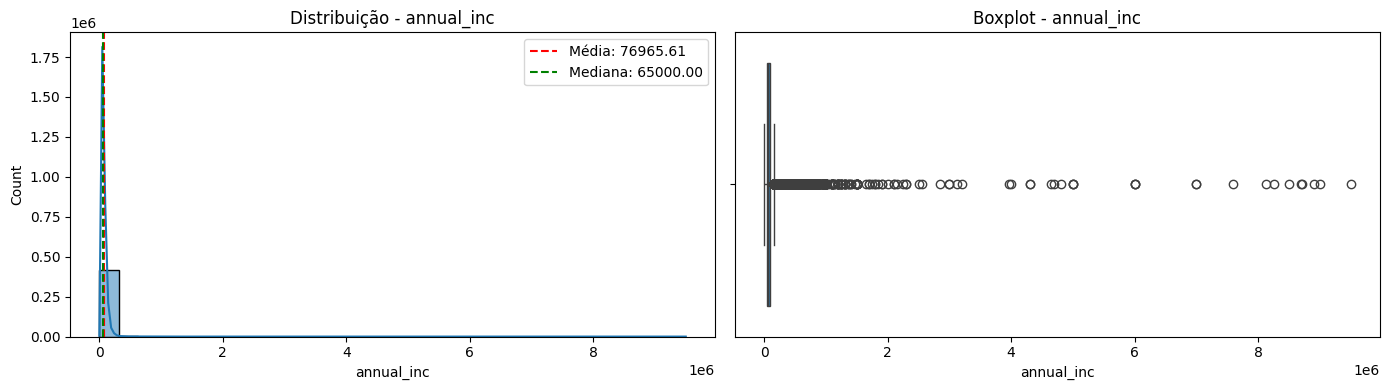


📊 ANÁLISE: dti
✅ Total de valores: 421,094
⚠️ Valores nulos: 0 (0.00%)
📊 Média: 19.20
📊 Mediana: 18.60
📊 Desvio Padrão: 23.50
📊 Mínimo: 0.00
📊 Máximo: 9,999.00
📊 Q1 (25%): 12.59
📊 Q2 (50% / Mediana): 18.60
📊 Q3 (75%): 25.34
📊 IQR (Q3-Q1): 12.75
📊 Limite inferior (outlier): -6.54
📊 Limite superior (outlier): 44.47
📊 Assimetria (skewness): 363.87
📊 Curtose: 154383.10


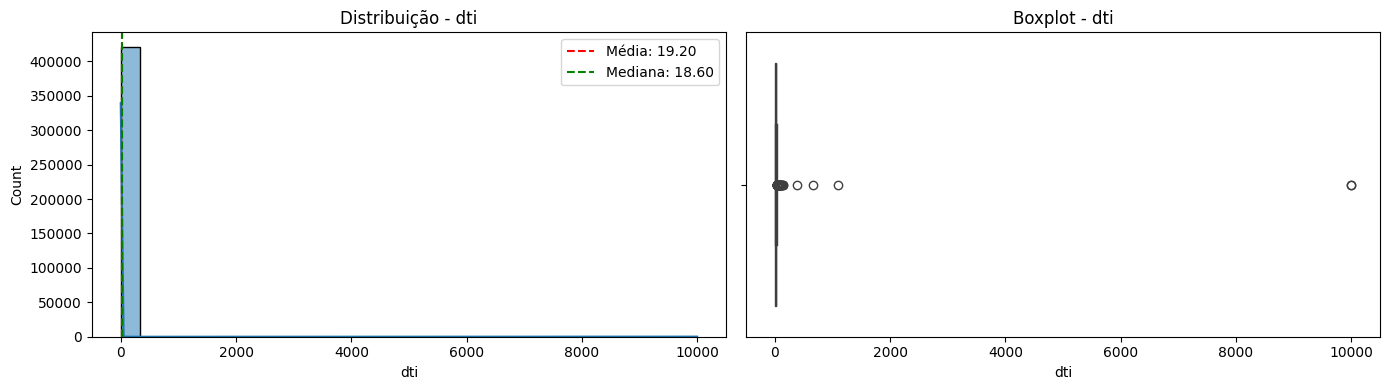


📊 ANÁLISE: delinq_2yrs
✅ Total de valores: 421,094
⚠️ Valores nulos: 0 (0.00%)
📊 Média: 0.35
📊 Mediana: 0.00
📊 Desvio Padrão: 0.93
📊 Mínimo: 0.00
📊 Máximo: 39.00
📊 Q1 (25%): 0.00
📊 Q2 (50% / Mediana): 0.00
📊 Q3 (75%): 0.00
📊 IQR (Q3-Q1): 0.00
📊 Limite inferior (outlier): 0.00
📊 Limite superior (outlier): 0.00
📊 Assimetria (skewness): 5.48
📊 Curtose: 57.61


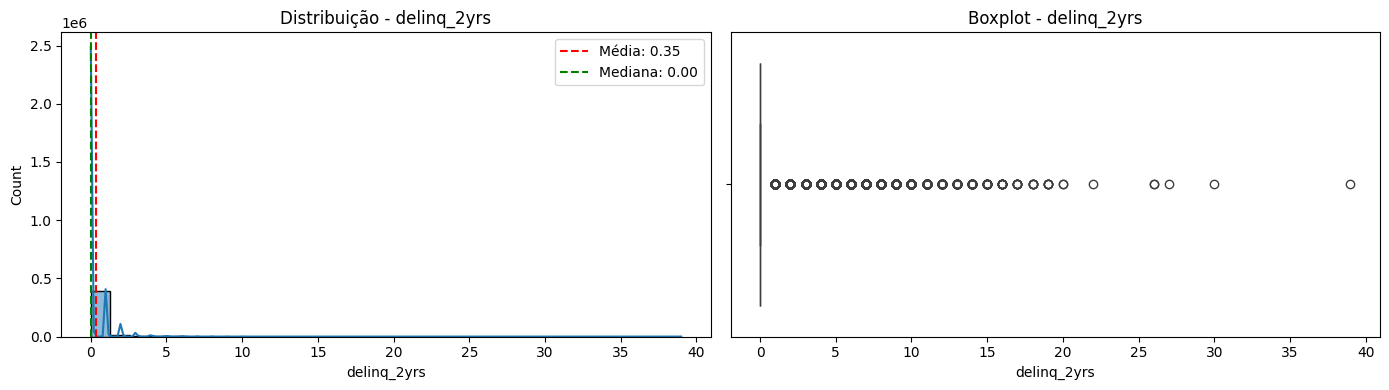

In [7]:
# ===========================================
# 🔍 ANÁLISE DETALHADA DAS PRINCIPAIS COLUNAS
# ===========================================

# Selecionar colunas numéricas
colunas_numericas = df_dataset.select_dtypes(include=['int64', 'float64']).columns

for col in colunas_numericas[:10]:  # Analisa as 10 primeiras (ajuste conforme necessário)
    print("\n" + "=" * 50)
    print(f"📊 ANÁLISE: {col}")
    print("=" * 50)

    dados = df_dataset[col].dropna()

    print(f"✅ Total de valores: {len(dados):,}")
    print(f"⚠️ Valores nulos: {df_dataset[col].isnull().sum()} ({df_dataset[col].isnull().mean():.2%})")
    print(f"📊 Média: {dados.mean():,.2f}")
    print(f"📊 Mediana: {dados.median():,.2f}")
    print(f"📊 Desvio Padrão: {dados.std():,.2f}")
    print(f"📊 Mínimo: {dados.min():,.2f}")
    print(f"📊 Máximo: {dados.max():,.2f}")

    # Quartis
    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1

    print(f"📊 Q1 (25%): {q1:,.2f}")
    print(f"📊 Q2 (50% / Mediana): {dados.median():,.2f}")
    print(f"📊 Q3 (75%): {q3:,.2f}")
    print(f"📊 IQR (Q3-Q1): {iqr:,.2f}")
    print(f"📊 Limite inferior (outlier): {q1 - 1.5 * iqr:,.2f}")
    print(f"📊 Limite superior (outlier): {q3 + 1.5 * iqr:,.2f}")

    # Assimetria e Curtose
    print(f"📊 Assimetria (skewness): {dados.skew():.2f}")
    print(f"📊 Curtose: {dados.kurtosis():.2f}")

    # Histograma
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(dados, kde=True, bins=30)
    plt.axvline(dados.mean(), color='red', linestyle='--', label=f'Média: {dados.mean():.2f}')
    plt.axvline(dados.median(), color='green', linestyle='--', label=f'Mediana: {dados.median():.2f}')
    plt.title(f'Distribuição - {col}')
    plt.legend()

    plt.subplot(1, 2, 2)
    sns.boxplot(x=dados)
    plt.title(f'Boxplot - {col}')

    plt.tight_layout()
    plt.show()

## Relatório Automático de Insights

In [8]:
# ===========================================
# 📝 RELATÓRIO AUTOMÁTICO DE INSIGHTS
# ===========================================

print("\n" + "=" * 70)
print("📝 RELATÓRIO DE INSIGHTS DAS ESTATÍSTICAS")
print("=" * 70)

# Analisar cada coluna numérica
# Redefinir colunas_numericas para refletir as colunas atuais do df_dataset
colunas_numericas = df_dataset.select_dtypes(include=['int64', 'float64']).columns

for col in colunas_numericas:
    dados = df_dataset[col].dropna()

    if len(dados) == 0:
        continue

    media = dados.mean()
    mediana = dados.median()
    desvio = dados.std()
    assimetria = dados.skew()
    nulos_pct = df_dataset[col].isnull().mean()
    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    minimo = dados.min()
    maximo = dados.max()

    insights = []

    # Verificar nulos
    if nulos_pct > 0.5:
        insights.append(f"⚠️ ALERTA: Mais de 50% de dados nulos ({nulos_pct:.1%})")
    elif nulos_pct > 0.1:
        insights.append(f"⚠️ Atenção: {nulos_pct:.1%} de dados nulos")

    # Verificar assimetria
    if abs(assimetria) > 1:
        direcao = "direita (valores altos)" if assimetria > 0 else "esquerda (valores baixos)"
        insights.append(f"📊 Distribuição assimétrica à {direcao}")

    # Verificar diferença média/mediana
    if abs(media - mediana) / max(abs(media), abs(mediana), 1) > 0.2:
        insights.append(f"📊 Média ({media:,.2f}) e Mediana ({mediana:,.2f}) muito diferentes → presença de outliers")

    # Verificar outliers
    iqr = q3 - q1
    limite_sup = q3 + 1.5 * iqr
    outliers_pct = (dados > limite_sup).mean()
    if outliers_pct > 0.05:
        insights.append(f"📊 {outliers_pct:.1%} de outliers acima do limite superior")

    # Verificar variabilidade
    cv = desvio / max(abs(media), 1) if media != 0 else 0
    if cv > 1:
        insights.append(f"📊 Alta variabilidade (CV = {cv:.2f})")

    # Verificar valores negativos (incomum em dados financeiros)
    if minimo < 0:
        insights.append(f"⚠️ Presença de valores negativos (mín: {minimo:,.2f})")

    if insights:
        print(f"\n🔹 {col}:")
        for insight in insights:
            print(f"   {insight}")

print("\n" + "=" * 70)


📝 RELATÓRIO DE INSIGHTS DAS ESTATÍSTICAS

🔹 annual_inc:
   📊 Distribuição assimétrica à direita (valores altos)

🔹 dti:
   📊 Distribuição assimétrica à direita (valores altos)
   📊 Alta variabilidade (CV = 1.22)

🔹 delinq_2yrs:
   📊 Distribuição assimétrica à direita (valores altos)
   📊 Média (0.35) e Mediana (0.00) muito diferentes → presença de outliers
   📊 20.7% de outliers acima do limite superior

🔹 inq_last_6mths:
   📊 Distribuição assimétrica à direita (valores altos)
   📊 Média (0.57) e Mediana (0.00) muito diferentes → presença de outliers

🔹 mths_since_last_delinq:
   ⚠️ Atenção: 48.4% de dados nulos

🔹 mths_since_last_record:
   ⚠️ ALERTA: Mais de 50% de dados nulos (82.3%)

🔹 open_acc:
   📊 Distribuição assimétrica à direita (valores altos)

🔹 pub_rec:
   📊 Distribuição assimétrica à direita (valores altos)
   📊 Média (0.23) e Mediana (0.00) muito diferentes → presença de outliers
   📊 17.7% de outliers acima do limite superior

🔹 revol_bal:
   📊 Distribuição assimétrica

## Resumo Executivo das Principais Variáveis

In [9]:
# ===========================================
# 🎯 RESUMO EXECUTIVO
# ===========================================

print("\n" + "=" * 70)
print("🎯 RESUMO EXECUTIVO DAS PRINCIPAIS VARIÁVEIS")
print("=" * 70)

variaveis_chave = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util', 'fico_range_low']

for var in variaveis_chave:
    if var in df_dataset.columns:
        dados = df_dataset[var].dropna()
        print(f"\n📊 {var}:")
        print(f"   Média: {dados.mean():,.2f} | Mediana: {dados.median():,.2f}")
        print(f"   Q1: {dados.quantile(0.25):,.2f} | Q3: {dados.quantile(0.75):,.2f}")
        print(f"   Mín: {dados.min():,.2f} | Máx: {dados.max():,.2f}")
        print(f"   Desvio Padrão: {dados.std():,.2f} | Assimetria: {dados.skew():.2f}")
        print(f"   Nulos: {df_dataset[var].isnull().sum()} ({df_dataset[var].isnull().mean():.2%})")


🎯 RESUMO EXECUTIVO DAS PRINCIPAIS VARIÁVEIS

📊 loan_amnt:
   Média: 15,240.26 | Mediana: 14,000.00
   Q1: 8,500.00 | Q3: 20,000.00
   Mín: 1,000.00 | Máx: 35,000.00
   Desvio Padrão: 8,571.31 | Assimetria: 0.63
   Nulos: 0 (0.00%)

📊 int_rate:
   Média: 12.60 | Mediana: 12.29
   Q1: 9.17 | Q3: 15.59
   Mín: 5.32 | Máx: 28.99
   Desvio Padrão: 4.32 | Assimetria: 0.56
   Nulos: 0 (0.00%)

📊 annual_inc:
   Média: 76,965.61 | Mediana: 65,000.00
   Q1: 46,000.00 | Q3: 91,691.25
   Mín: 0.00 | Máx: 9,500,000.00
   Desvio Padrão: 73,950.05 | Assimetria: 49.29
   Nulos: 0 (0.00%)

📊 dti:
   Média: 19.20 | Mediana: 18.60
   Q1: 12.59 | Q3: 25.34
   Mín: 0.00 | Máx: 9,999.00
   Desvio Padrão: 23.50 | Assimetria: 363.87
   Nulos: 0 (0.00%)

📊 revol_util:
   Média: 53.84 | Mediana: 54.20
   Q1: 36.10 | Q3: 72.10
   Mín: 0.00 | Máx: 193.00
   Desvio Padrão: 23.89 | Assimetria: -0.08
   Nulos: 162 (0.04%)


## Significado das Métricas Estatísticas


In [10]:
from IPython.display import display, Markdown

tabela = """
# -------------------------------------------
# 📊 Significado das Métricas Estatísticas
# -------------------------------------------

| Métrica | Significado | Interpretação |
|:--------|:------------|:--------------|
| **Média** | Valor central (soma ÷ total) | Sensível a outliers |
| **Mediana** | Valor do meio (50% abaixo, 50% acima) | Robusta a outliers |
| **Desvio Padrão** | Dispersão dos dados | Quanto maior, mais espalhados |
| **Q1 (25%)** | 25% dos dados abaixo deste valor | Primeiro quartil |
| **Q3 (75%)** | 75% dos dados abaixo deste valor | Terceiro quartil |
| **IQR** | Q3 - Q1 | Intervalo interquartil |
| **Assimetria** | Para onde a cauda puxa | >0 = cauda à direita, <0 = esquerda |
| **Outlier** | Valor > Q3 + 1.5×IQR | Dados muito extremos |
"""

display(Markdown(tabela))


# -------------------------------------------
# 📊 Significado das Métricas Estatísticas
# -------------------------------------------

| Métrica | Significado | Interpretação |
|:--------|:------------|:--------------|
| **Média** | Valor central (soma ÷ total) | Sensível a outliers |
| **Mediana** | Valor do meio (50% abaixo, 50% acima) | Robusta a outliers |
| **Desvio Padrão** | Dispersão dos dados | Quanto maior, mais espalhados |
| **Q1 (25%)** | 25% dos dados abaixo deste valor | Primeiro quartil |
| **Q3 (75%)** | 75% dos dados abaixo deste valor | Terceiro quartil |
| **IQR** | Q3 - Q1 | Intervalo interquartil |
| **Assimetria** | Para onde a cauda puxa | >0 = cauda à direita, <0 = esquerda |
| **Outlier** | Valor > Q3 + 1.5×IQR | Dados muito extremos |


#Limpeza e Tratamento dos Dados

In [11]:
#Lista das colunas que possuem mais de 80% de valores nulos
na_values = df_dataset.isnull().mean()
na_values[na_values>0.8]

,0
desc,0.999893
mths_since_last_record,0.823282
annual_inc_joint,0.998786
dti_joint,0.998791
verification_status_joint,0.998786
open_acc_6m,0.949246
open_il_6m,0.949246
open_il_12m,0.949246
open_il_24m,0.949246
mths_since_rcnt_il,0.950581


In [12]:
#Eliminar colunas com mais de 80% de valores nulos
df_dataset.dropna(thresh = df_dataset.shape[0]*0.2, axis = 1, inplace = True)

#Remover colunas redundantes e forward-looking
df_dataset.drop(columns = ['id', 'member_id', 'sub_grade', 'emp_title', 'url', 'title', 'zip_code', 'next_pymnt_d',
                          'recoveries', 'collection_recovery_fee', 'total_rec_prncp', 'total_rec_late_fee'], inplace = True, errors='ignore')

💡Colunas Redundantes são colunas que repetem algo que já existe ou são inúteis para o modelo.

💡Colunas Forward-Looking são colunas com informações que só existem depois que o empréstimo termina

In [13]:
# --------------------------------------
# Verificar se as alterações deram certo
# --------------------------------------
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421094 entries, 0 to 421093
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    421094 non-null  int64  
 1   funded_amnt                  421094 non-null  int64  
 2   funded_amnt_inv              421094 non-null  int64  
 3   term                         421094 non-null  object 
 4   int_rate                     421094 non-null  float64
 5   installment                  421094 non-null  float64
 6   grade                        421094 non-null  object 
 7   emp_length                   397277 non-null  object 
 8   home_ownership               421094 non-null  object 
 9   annual_inc                   421094 non-null  float64
 10  verification_status          421094 non-null  object 
 11  issue_d                      421094 non-null  object 
 12  loan_status                  421094 non-null  object 
 13 

#Definir Target

In [14]:
df_dataset['loan_status'].value_counts(normalize = True)

,proportion
loan_status,
Current,0.896600
Fully Paid,0.054582
Issued,0.020091
Late (31-120 days),0.011140
In Grace Period,0.007378
Charged Off,0.006585
Late (16-30 days),0.002705
Default,0.000919


📊 Distribuição da coluna `loan_status`:
---

Esta coluna possui 8 categorias

---
| Cor | Valor               | %     | Tipo                          |
|-----|---------------------|-------|-------------------------------|
| 🟡  | Current             | 89.7% | Pagando em dia                |
| 🟢  | Fully Paid          | 5.5%  | Pagou tudo                    |
| 🟡  | Issued              | 2.0%  | Empréstimo recém-emitido      |
| 🔴  | Late (31-120 days)  | 1.1%  | Atraso grave (mau pagador)    |
| 🟡  | In Grace Period     | 0.7%  | Período de carência           |
| 🔴  | Charged Off         | 0.6%  | Banco declarou como perda     |
| 🔴  | Late (16-30 days)   | 0.3%  | Atraso leve (mau pagador)     |
| 🔴  | Default             | 0.1%  | Calote (parou de pagar)       |
---

> 🟢 = Bom pagador | 🟡 = Indefinido/Neutro | 🔴 = Mau pagador




#Converter a coluna loan_status em Target Binário (0,1)

In [15]:
if 'loan_status' in df_dataset.columns:
    #Criar uma nova coluna (good_bad) baseada na coluna loan_status que será a variável alvo
    df_dataset['good_bad'] = np.where(df_dataset.loc[:, 'loan_status'].isin(['Charged Off', 'Default', 'Late (31-120 days)',
                                                                           'Does not meet the credit policy. Status:Charged Off']), 0, 1)
    #Eliminar a coluna original loan_status
    df_dataset.drop(columns = ['loan_status'], inplace = True)
else:
    print("A coluna 'loan_status' já foi processada ou não existe.")

💡 Foi criada uma nova coluna (good_bad) a partir da coluna loan_status para converter os dados desta coluna em uma variável alvo binária, onde 0 representa maus pagadores e 1 representa bons pagadores.

💡 Após criar a variável alvo binária (good_bad), a coluna loan_status foi removida para evitar vazamento de dados, pois o modelo deve prever o risco, não consultar o resultado. Manter a coluna loan_status seria como entregar o gabarito da prova.

#Dividir os Dados para o Treinamento

In [16]:
# -------------------------------------------
# Dividir os Dados em Treino e Teste (80/20)
# -------------------------------------------
# Importar a biblioteca sklearn
# -------------------------------------------

from sklearn.model_selection import train_test_split

In [17]:
#Dividir os dados em 80% treino e 20% teste, mantendo a proporção de maus pagadores igual nos dois conjuntos

X = df_dataset.drop('good_bad', axis = 1)
y = df_dataset['good_bad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)


X_train, X_test = X_train.copy(), X_test.copy()

💡 O código separa os dados em duas partes: 80% para o modelo aprender (treino) e 20% para avaliar se aprendeu certo (teste), mantendo a proporção de bons e maus pagadores igual nas duas.

#Tratamento de Variáveis Categóricas

In [18]:
# -------------------------------------------
# Converter as colunas de texto em numéricas
# -------------------------------------------
from sklearn.preprocessing import LabelEncoder

def converter_todas_strings(df_treino, df_teste):
    # Identificar colunas de texto
    colunas_texto = df_treino.select_dtypes(include='object').columns

    for col in colunas_texto:
        n_unique = df_treino[col].nunique()

        if n_unique <= 10:
            # Poucas categorias → Label Encoding
            le = LabelEncoder()
            df_treino[col] = le.fit_transform(df_treino[col].astype(str))
            df_teste[col] = le.transform(df_teste[col].astype(str))
        else:
            # Muitas categorias → One-Hot Encoding
            df_treino = pd.get_dummies(df_treino, columns=[col], drop_first=True)
            df_teste = pd.get_dummies(df_teste, columns=[col], drop_first=True)

    # -------------------------------------------
    # Alinhar colunas do teste com as do treino
    # -------------------------------------------
    df_teste = df_teste.reindex(columns=df_treino.columns, fill_value=0)

    return df_treino, df_teste

# -------------------------------------------
# Aplicar a função
# -------------------------------------------
X_train, X_test = converter_todas_strings(X_train, X_test)

# -------------------------------------------
# Verificar resultado
# -------------------------------------------
print(f"✅ Colunas restantes: {X_train.shape[1]}")
print(f"✅ Ainda há texto? {(X_train.dtypes == 'object').any()}")

✅ Colunas restantes: 800
✅ Ainda há texto? False


Foi feito a conversão de todas as colunas 'object' em 'numéricas'

In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 336875 entries, 304531 to 312076
Columns: 800 entries, loan_amnt to last_credit_pull_d_Sep-15
dtypes: bool(765), float64(13), int64(22)
memory usage: 338.3 MB


In [20]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84219 entries, 85226 to 118334
Columns: 800 entries, loan_amnt to last_credit_pull_d_Sep-15
dtypes: bool(719), float64(13), int64(68)
memory usage: 110.4 MB


#Modelagem

##Modelo XGBoost para Classificação de Crédito
---
Importar as Bibliotecas e Treinar o Modelo

🔄 Treinando o modelo...
✅ Modelo treinado com sucesso!

📊 Previsões realizadas: 84219 amostras

📊 MATRIZ DE CONFUSÃO


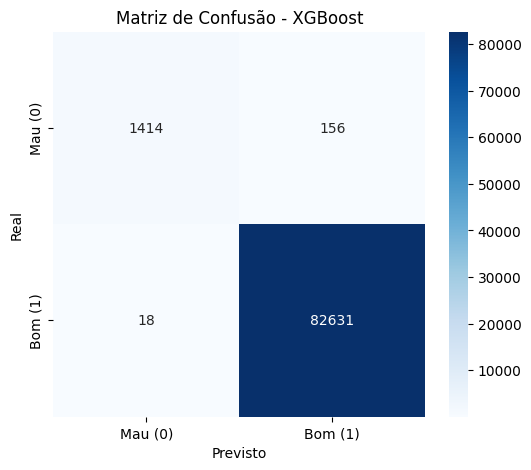

✅ Verdadeiros Negativos (acertou ruins): 1414
❌ Falsos Positivos (errou como ruim): 156
❌ Falsos Negativos (errou como bom): 18
✅ Verdadeiros Positivos (acertou bons): 82631

📋 RELATÓRIO DE CLASSIFICAÇÃO
                 precision    recall  f1-score   support

Mau Pagador (0)       0.99      0.90      0.94      1570
Bom Pagador (1)       1.00      1.00      1.00     82649

       accuracy                           1.00     84219
      macro avg       0.99      0.95      0.97     84219
   weighted avg       1.00      1.00      1.00     84219


🎯 AUC-ROC: 0.9895


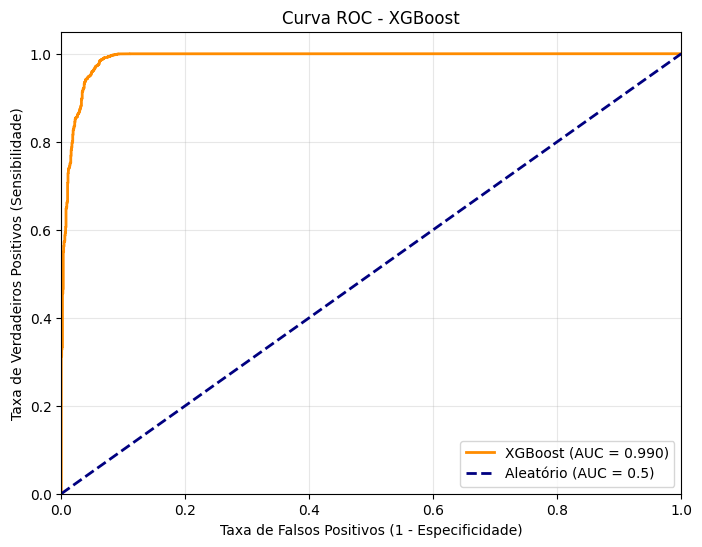


🎯 RESUMO DO MODELO XGBOOST
🔹 Acurácia: 99.79%
🔹 Precisão (Bons): 99.81%
🔹 Recall (Bons): 99.98%
🔹 AUC-ROC: 0.9895
🔹 Total de previsões: 84219


In [21]:
# 📚 Importar bibliotecas
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Função para sanitizar nomes de colunas (padronizar e limpar)
def sanitize_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.replace('[', '_').replace(']', '_').replace('<', '_').replace(' ', '_').replace('-', '_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# Sanitizar nomes das colunas em X_train e X_test
X_train = sanitize_col_names(X_train)
X_test = sanitize_col_names(X_test)

# Criar o modelo
modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Treinar o modelo
print("🔄 Treinando o modelo...")
modelo_xgb.fit(X_train, y_train)
print("✅ Modelo treinado com sucesso!")

# Previsões no conjunto de teste
y_pred = modelo_xgb.predict(X_test)          # Classes (0 ou 1)
y_pred_proba = modelo_xgb.predict_proba(X_test)[:, 1]  # Probabilidades

print(f"\n📊 Previsões realizadas: {len(y_pred)} amostras")

# -------------------------------------------
# AVALIAR O MODELO
# -------------------------------------------

# Matriz de Confusão
print("\n" + "="*50)
print("📊 MATRIZ DE CONFUSÃO")
print("="*50)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Mau (0)', 'Bom (1)'],
            yticklabels=['Mau (0)', 'Bom (1)'])
plt.title('Matriz de Confusão - XGBoost')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# Explicação da matriz
vn, fp, fn, vp = cm.ravel()
print(f"✅ Verdadeiros Negativos (acertou ruins): {vn}")
print(f"❌ Falsos Positivos (errou como ruim): {fp}")
print(f"❌ Falsos Negativos (errou como bom): {fn}")
print(f"✅ Verdadeiros Positivos (acertou bons): {vp}")

# Relatório de Classificação
print("\n" + "="*50)
print("📋 RELATÓRIO DE CLASSIFICAÇÃO")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Mau Pagador (0)', 'Bom Pagador (1)']))

# AUC-ROC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n🎯 AUC-ROC: {roc_auc:.4f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
plt.title('Curva ROC - XGBoost')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------------------
# Resumo final
# -------------------------------------------

print("\n" + "="*50)
print("🎯 RESUMO DO MODELO XGBOOST")
print("="*50)
print(f"🔹 Acurácia: {(vp + vn) / len(y_test):.2%}")
print(f"🔹 Precisão (Bons): {vp / (vp + fp):.2%}")
print(f"🔹 Recall (Bons): {vp / (vp + fn):.2%}")
print(f"🔹 AUC-ROC: {roc_auc:.4f}")
print(f"🔹 Total de previsões: {len(y_pred)}")


##Modelo Regressão Logística - Risco de Crédito
---
Importar as Bibliotecas e Treinar o Modelo

🔄 Garantindo que todas as colunas são numéricas e tratando NaNs...
✅ Colunas garantidas como numéricas e NaNs tratados!
🔄 Verificando e removendo colunas com variância zero...
   Colunas com variância zero encontradas e removidas: ['policy_code']
✅ Colunas com variância zero tratadas!
🔄 Verificando NaNs restantes antes da padronização (safeguard)...
   Nenhum NaN restante encontrado antes da padronização.
🔄 Padronizando os dados...
✅ Dados padronizados!
🔄 Treinando Regressão Logística...
✅ Modelo treinado!


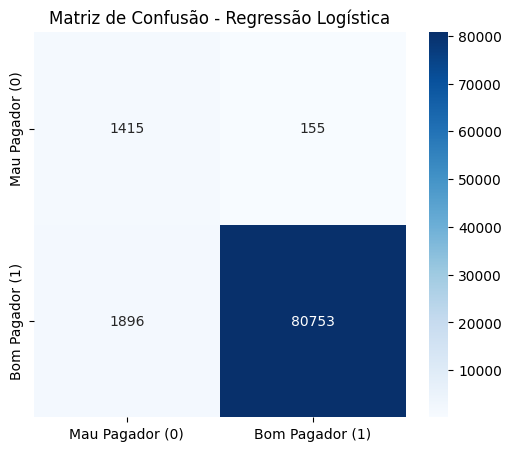

✅ Acertou Ruins Pagadores: 1415
❌ Errou como Ruins Pagadores: 155
❌ Falsos Negativos (errou como bons pagadores): 1896
✅ Acertou Bons Pagadores: 80753

📋 RELATÓRIO DE CLASSIFICAÇÃO:
                 precision    recall  f1-score   support

Mau Pagador (0)       0.43      0.90      0.58      1570
Bom Pagador (1)       1.00      0.98      0.99     82649

       accuracy                           0.98     84219
      macro avg       0.71      0.94      0.78     84219
   weighted avg       0.99      0.98      0.98     84219

🎯 AUC-ROC: 0.9769


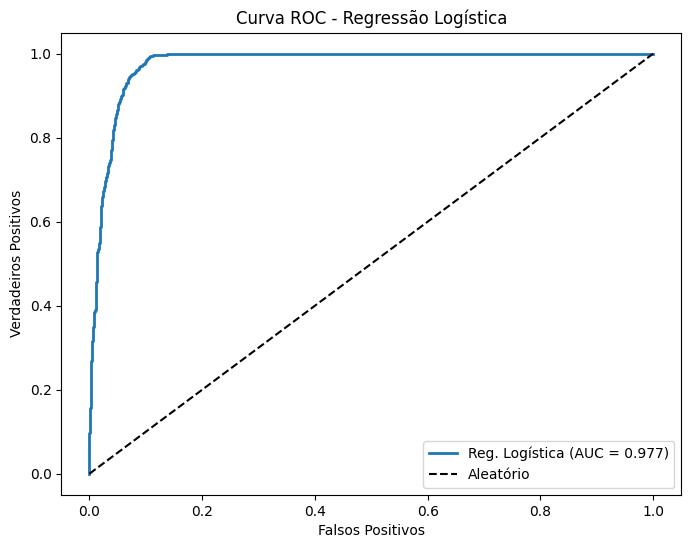


🎯 RESUMO DO MODELO REGRESSÃO LOGÍSTICA
🔹 Acurácia: 97.56%
🔹 Precisão (Bons Pagadores): 99.81%
🔹 Recall (Bons Pagadores): 97.71%
🔹 AUC-ROC: 0.9769
🔹 Total de previsões: 84219


In [22]:
# 📚 Importar bibliotecas
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Importar pandas para pd.to_numeric e fillna
import numpy as np # Importar numpy para np.isclose

# ==================================================
# ⚙️ Garantir dados numéricos e Tratamento de NaNs
# ==================================================

print("🔄 Garantindo que todas as colunas são numéricas e tratando NaNs...")
# 1. Forçar a conversão de todas as colunas para numérico, transformando erros em NaN
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# 2. Imputar NaNs restantes (se houver)
cols_with_nan_after_coerce_train = X_train.columns[X_train.isnull().any()].tolist()
if cols_with_nan_after_coerce_train:
    for col in cols_with_nan_after_coerce_train:
        # Calcular a média. Se a coluna for toda NaN, mean_val será NaN.
        mean_val = X_train[col].mean()

        # Se mean_val for NaN (indicando que a coluna inteira é NaN), preencher com 0
        if pd.isna(mean_val):
            fill_value = 0
        else:
            fill_value = mean_val

        X_train[col] = X_train[col].fillna(fill_value)
        X_test[col] = X_test[col].fillna(fill_value)
print("✅ Colunas garantidas como numéricas e NaNs tratados!")

# 3. Remover colunas com variância zero para evitar NaNs após StandardScaler
print("🔄 Verificando e removendo colunas com variância zero...")
zero_var_cols = X_train.columns[X_train.std() == 0].tolist()

if zero_var_cols:
    print(f"   Colunas com variância zero encontradas e removidas: {zero_var_cols}")
    X_train = X_train.drop(columns=zero_var_cols)
    X_test = X_test.drop(columns=zero_var_cols)
else:
    print("   Nenhuma coluna com variância zero encontrada.")
print("✅ Colunas com variância zero tratadas!")

# 4. Final check for any remaining NaNs in X_train and X_test before scaling
print("🔄 Verificando NaNs restantes antes da padronização (safeguard)...")
nan_count_train_before_scale = X_train.isnull().sum().sum()
nan_count_test_before_scale = X_test.isnull().sum().sum()

if nan_count_train_before_scale > 0 or nan_count_test_before_scale > 0:
    print(f"   ⚠️ NaNs encontrados em X_train: {nan_count_train_before_scale}, em X_test: {nan_count_test_before_scale}. Preenchendo com 0.")
    X_train = X_train.fillna(0)
    X_test = X_test.fillna(0)
else:
    print("   Nenhum NaN restante encontrado antes da padronização.")

# Agora, padronizar os dados
print("🔄 Padronizando os dados...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Dados padronizados!")

# ===========================================
# 🤖 TREINAR O MODELO
# ===========================================
modelo_lr = LogisticRegression(
    class_weight='balanced',  # Lida com desbalanceamento
    max_iter=1000,            # Aumenta iterações
    random_state=42
)

print("🔄 Treinando Regressão Logística...")
modelo_lr.fit(X_train_scaled, y_train)
print("✅ Modelo treinado!")

# ===========================================
# 📊 PREVISÕES
# ===========================================
y_pred = modelo_lr.predict(X_test_scaled)
y_pred_proba = modelo_lr.predict_proba(X_test_scaled)[:, 1]

# ===========================================
# 📈 AVALIAÇÃO
# ===========================================

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
vn, fp, fn, vp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Mau Pagador (0)', 'Bom Pagador (1)'],
            yticklabels=['Mau Pagador (0)', 'Bom Pagador (1)'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

print(f"✅ Acertou Ruins Pagadores: {vn}")
print(f"❌ Errou como Ruins Pagadores: {fp}")
print(f"❌ Falsos Negativos (errou como bons pagadores): {fn}")
print(f"✅ Acertou Bons Pagadores: {vp}")

# Relatório de Classificação
print("\n📋 RELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, y_pred, target_names=['Mau Pagador (0)', 'Bom Pagador (1)']))

# AUC-ROC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"🎯 AUC-ROC: {roc_auc:.4f}")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Reg. Logística (AUC = {roc_auc:.3f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdadeiros Positivos')
plt.title('Curva ROC - Regressão Logística')
plt.legend()
plt.show()

# Resumo final

print("\n" + "="*50)
print("🎯 RESUMO DO MODELO REGRESSÃO LOGÍSTICA")
print("="*50)
print(f"🔹 Acurácia: {(vp + vn) / len(y_test):.2%}")
print(f"🔹 Precisão (Bons Pagadores): {vp / (vp + fp):.2%}")
print(f"🔹 Recall (Bons Pagadores): {vp / (vp + fn):.2%}")
print(f"🔹 AUC-ROC: {roc_auc:.4f}")
print(f"🔹 Total de previsões: {len(y_pred)}")

##Moledo Tensorflow
---
Importar as Bibliotecas e Treinar o Modelo

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        51,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,825 (210.25 KB)

 Trainable params: 53,825 (210.25 KB)

 Non-trainable params: 0 (0.00 B)


🔄 Treinando a rede neural...
Epoch 1/50
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9748 - auc: 0.8981 - loss: 0.0798 - val_accuracy: 0.9952 - val_auc: 0.9468 - val_loss: 0.0284
Epoch 2/50
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9946 - auc: 0.9495 - loss: 0.0317 - val_accuracy: 0.9960 - val_auc: 0.9487 - val_loss: 0.0244
Epoch 3/50
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9958 - auc: 0.9600 - loss: 0.0246 - val_accuracy: 0.9964 - val_auc: 0.9529 - val_loss: 0.0221
Epoch 4/50
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9963 - auc: 0.9644 - loss: 0.0211 - val_accuracy: 0.9966 - val_auc: 0.9520 - val_loss: 0.0225
Epoch 5/50
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9967 - auc: 0.9671 - loss: 0.0197 - val_accuracy: 0.9967 - val_auc: 0.9486 - val_loss: 0.0221
Epoch 6/50
1053/1053 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9968 - auc: 0.9727 - loss: 0.0181 - val_accuracy: 0.9968 - val_auc: 0.9583 - val_loss: 0.0

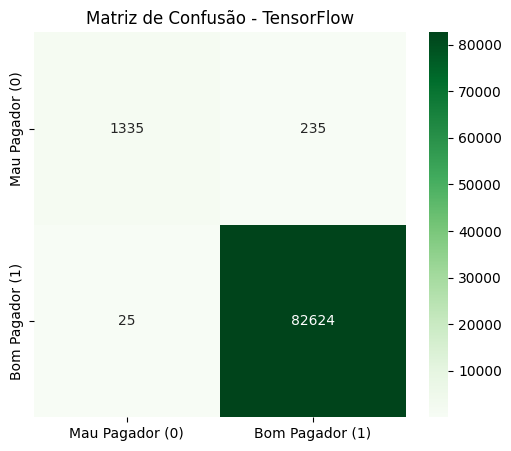

✅ Acertou Ruins Pagadores: 1335
❌ Errou como Ruins Pagadores: 235
❌ Errou como Bons Pagadores: 25
✅ Acertou Bons Pagadores: 82624

📋 Relatório de Classificação:
                 precision    recall  f1-score   support

Mau Pagador (0)       0.98      0.85      0.91      1570
Bom Pagador (1)       1.00      1.00      1.00     82649

       accuracy                           1.00     84219
      macro avg       0.99      0.93      0.95     84219
   weighted avg       1.00      1.00      1.00     84219

🎯 AUC-ROC: 0.9762


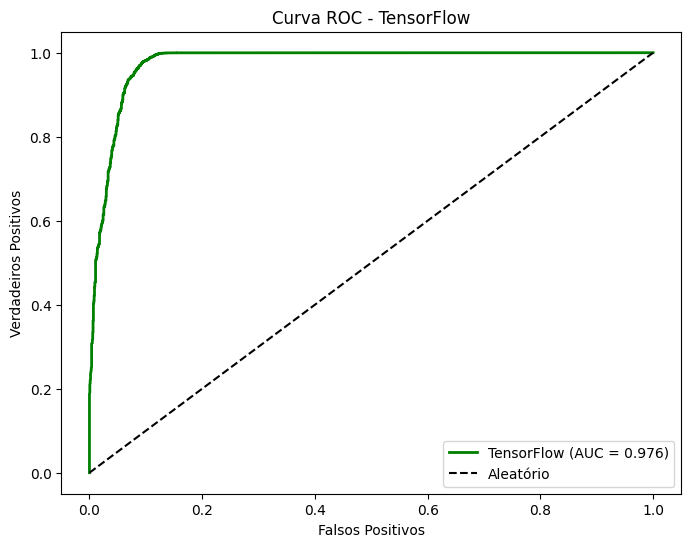

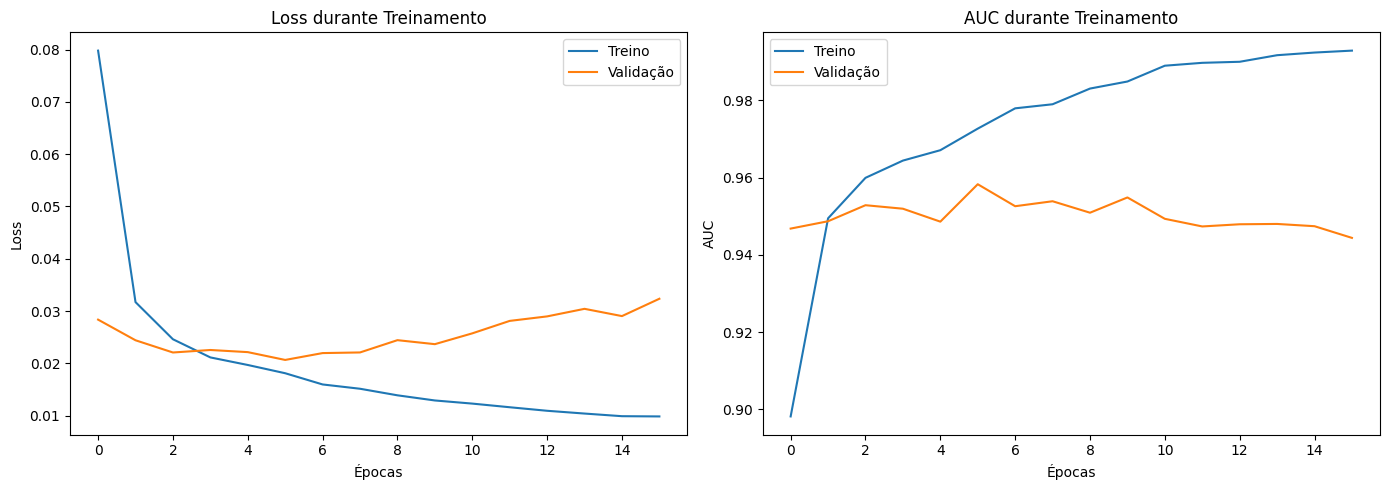


🎯 RESUMO DO MODELO TENSORFLOW
🔹 Acurácia: 99.69%
🔹 Precisão (Bons Pagadores): 99.72%
🔹 Recall (Bons Pagadores): 99.97%
🔹 AUC-ROC: 0.9762
🔹 Total de previsões: 84219


In [23]:
# 📚 Importar bibliotecas
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===========================================
# ⚙️ Padronizar os dados
# ===========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===========================================
# 🧠 CRIAR O MODELO
# ===========================================
modelo_tf = keras.Sequential([
    # Camada de entrada
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),  # Evita overfitting

    # Camada oculta 1
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),

    # Camada oculta 2
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),

    # Camada de saída (1 neurônio com sigmoid para binário)
    layers.Dense(1, activation='sigmoid')
])

# Compilar o modelo
modelo_tf.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Resumo do modelo
modelo_tf.summary()

# ===========================================
# 🔄 TREINAR
# ===========================================
print("\n🔄 Treinando a rede neural...")
historico = modelo_tf.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)
print("✅ Modelo treinado!")

# ===========================================
# 📊 PREVISÕES
# ===========================================
y_pred_proba = modelo_tf.predict(X_test_scaled).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

# ===========================================
# 📈 AVALIAÇÃO
# ===========================================

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
vn, fp, fn, vp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Mau Pagador (0)', 'Bom Pagador (1)'],
            yticklabels=['Mau Pagador (0)', 'Bom Pagador (1)'])
plt.title('Matriz de Confusão - TensorFlow')
plt.show()

print(f"✅ Acertou Ruins Pagadores: {vn}")
print(f"❌ Errou como Ruins Pagadores: {fp}")
print(f"❌ Errou como Bons Pagadores: {fn}")
print(f"✅ Acertou Bons Pagadores: {vp}")

# Relatório
print("\n📋 Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Mau Pagador (0)', 'Bom Pagador (1)']))

# AUC-ROC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"🎯 AUC-ROC: {roc_auc:.4f}")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'TensorFlow (AUC = {roc_auc:.3f})', lw=2, color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdadeiros Positivos')
plt.title('Curva ROC - TensorFlow')
plt.legend()
plt.show()

# ===========================================
# 📉 GRÁFICO DE TREINAMENTO
# ===========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(historico.history['loss'], label='Treino')
axes[0].plot(historico.history['val_loss'], label='Validação')
axes[0].set_title('Loss durante Treinamento')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()

# AUC
axes[1].plot(historico.history['auc'], label='Treino')
axes[1].plot(historico.history['val_auc'], label='Validação')
axes[1].set_title('AUC durante Treinamento')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

# Resumo final

print("\n" + "="*50)
print("🎯 RESUMO DO MODELO TENSORFLOW")
print("="*50)
print(f"🔹 Acurácia: {(vp + vn) / len(y_test):.2%}")
print(f"🔹 Precisão (Bons Pagadores): {vp / (vp + fp):.2%}")
print(f"🔹 Recall (Bons Pagadores): {vp / (vp + fn):.2%}")
print(f"🔹 AUC-ROC: {roc_auc:.4f}")
print(f"🔹 Total de previsões: {len(y_pred)}")

# 📝 **Análise dos Resultados**

### **Principais Insights da Análise Estatística**

1.  **Dados Altamente Desbalanceados (Target)**
    *   A variável alvo (`good_bad`) está extremamente desbalanceada.
    *   92.4% dos empréstimos são classificados como "Bons Pagadores" (1).
    *   7.6% são "Maus Pagadores" (0).
    *   Impacto: Isso exige técnicas especiais durante a modelagem (como `class_weight='balanced'`) para que o modelo não aprenda a simplesmente "chutar" que todos são bons pagadores.

2.  **Presença Massiva de Outliers e Alta Assimetria**
    *   Praticamente todas as variáveis numéricas importantes apresentam distribuição assimétrica e forte presença de outliers. A média é consistentemente diferente da mediana, o que confirma a influência de valores extremos.
    *   **Exemplos Críticos:**
        *   `annual_inc` (Renda Anual): Média de 76.9k, mas a Mediana é de 65k, com máximo de 9.5 milhões.
        *   `revol_bal` (Saldo Rotativo): Média de 17.6k, Mediana de 11.9k, com alta variabilidade (CV = 1.37).
        *   `dti` (Relação Dívida/Renda): Média de 19.2, mas com máximo de 9.999, mostrando distorção nos dados.
    *   Impacto: Modelos lineares como a Regressão Logística são sensíveis a esses valores e exigem padronização e tratamento. Modelos baseados em árvore, como o XGBoost, são naturalmente mais robustos a eles.
---
###**Entendendo a Média e Mediana:**

Média: É a soma de todos os valores dividida pela quantidade. Ela é muito sensível a valores extremos.

Mediana: É o valor que está exatamente no meio do conjunto de dados, ela é robusta.

Quando a média é maior que a mediana, isso significa que existem valores muito altos (outliers) puxando a média para cima. É exatamente o que os resultados mostram.

Considerando a renda anual do cliente "típico" (mediana) é de 65 mil dólares por ano. A média de 76.9k é uma ilusão causada por pouquíssimos clientes "fora da curva".

---
3.  **Grande Quantidade de Dados Nulos (>80%)**
    *   Diversas colunas foram identificadas com mais de 80% dos valores ausentes.
    *   Exemplos: `mths_since_last_record` (82.3%), e várias colunas com informações dos últimos 6 a 24 meses, como `open_acc_6m`, `inq_last_12m`, etc. (94.9% de nulos).
    *   Impacto: Essas colunas foram removidas, pois possuem pouquíssima informação útil para os modelos preditivos.

4.  **Características do Perfil de Crédito**
    *   Taxa de Juros (`int_rate`): A taxa média é de 12.6%, variando de 5.3% a 28.9%.
    *   Valor do Empréstimo (`loan_amnt`): A maioria dos empréstimos está concentrada entre 8.5k e 20k, com um máximo de 35k.
    *   Histórico de Inadimplência (`delinq_2yrs`): A mediana é zero, mas a média é 0.35, com máximo de 39, indicando que uma minoria tem um histórico pesado de atrasos.

5.  **Problemas de Qualidade com Dados "Infinitos" ou Fora de Escala**
    *   As variáveis `dti` (máximo de 9999) e `annual_inc` (máximo de 9.5MM) possuem valores que parecem ser códigos de erro (placeholders) para dados ausentes, e não valores reais.
    *   Impacto: Esses valores precisam ser tratados como outliers ou erros, pois distorcem completamente a média e o desvio padrão.
    
---
### **Resumo Executivo das Variáveis Chave**

*   **`loan_amnt` (Valor do Empréstimo):** A maioria dos empréstimos é de até 20 mil dólares, com valores atípicos de 35 mil.
*   **`int_rate` (Taxa de Juros):** A taxa de juros tem uma distribuição relativamente simétrica, centrada em 12%.
*   **`annual_inc` (Renda Anual):** A renda é a variável mais problemática, com uma assimetria colossal (49.29) devido a valores extremos e inconsistentes (renda 0 ou 9.5 milhões).
*   **`dti` (Relação Dívida/Renda):** Apresenta a maior distorção (assimetria de 363), indicando a presença de valores irreais (9999), que devem ser tratados.
*   **`revol_util` (Taxa de Utilização do Rotativo):** É uma das poucas variáveis com distribuição próxima da normal, centrada em 54%.

## 📑 **Explicação e Funcionalidade dos Modelos**

Neste projeto, foram implementados três modelos de machine learning com o objetivo de prever se um cliente será um bom pagador (1) ou mau pagador (0), a partir de dados financeiros e de comportamento de crédito. Cada modelo utiliza uma abordagem matemática diferente para aprender padrões e tomar decisões.

---

## 1. XGBoost — `XGBClassifier`

XGBoost (Extreme Gradient Boosting) é um algoritmo de aprendizado de máquina baseado no conceito de gradiente boosting. Ele constrói múltiplas árvores de decisão de forma sequencial, onde cada nova árvore é treinada para corrigir os erros cometidos pelas árvores anteriores.

**Como funciona no projeto:**
- Constrói 100 árvores de decisão (`n_estimators=100`)
- Cada árvore tem no máximo 5 níveis de profundidade (`max_depth=5`)
- Aprende a uma taxa de 0.1 (`learning_rate=0.1`), equilibrando velocidade e precisão
- Não precisa de padronização dos dados, pois trabalha com comparações do tipo "valor maior que X"
- Lida naturalmente com valores ausentes, sem necessidade de pré-processamento adicional
- Combina as previsões de todas as árvores para tomar a decisão final

---

## 2. Regressão Logística — `LogisticRegression`

A Regressão Logística é um modelo estatístico clássico que utiliza uma função logística (curva em S) para estimar a probabilidade de um evento binário — neste caso, a probabilidade de um cliente ser bom pagador.

**Como funciona no projeto:**
- É um modelo linear, que atribui um peso (importância) a cada característica do cliente
- A soma ponderada dessas características passa por uma função sigmoide que gera uma probabilidade entre 0 e 1
- Requer padronização dos dados (`StandardScaler`) para que todas as características fiquem na mesma escala e o modelo funcione corretamente
- Utiliza `class_weight='balanced'` para compensar o desbalanceamento severo dos dados (≈90% bons pagadores vs. ≈10% maus pagadores), dando mais peso aos exemplos da classe minoritária durante o treinamento
- Por ser linear, é altamente interpretável: é fácil entender quais fatores mais influenciam a decisão do modelo

---

## 3. TensorFlow — Rede Neural Artificial

Uma rede neural artificial é um modelo de deep learning inspirado no funcionamento do cérebro humano. É composta por camadas de neurônios artificiais interconectados, capazes de aprender relações complexas e não lineares entre as características.

**Como funciona no projeto:**
- **Arquitetura em 3 camadas ocultas:**
  - Camada 1: 64 neurônios + Dropout 30%
  - Camada 2: 32 neurônios + Dropout 30%
  - Camada 3: 16 neurônios + Dropout 20%
- Todas as camadas usam função de ativação Relu para capturar relações não lineares
- Camada de saída com 1 neurônio e ativação Sigmoid para produzir probabilidade entre 0 e 1
- Dropout desativa aleatoriamente neurônios durante o treino para evitar overfitting (memorização dos dados)
- Treinado por até 50 épocas com EarlyStopping, que interrompe o treino quando o modelo para de melhorar
- Requer padronização dos dados (`StandardScaler`), assim como a Regressão Logística
- O aprendizado ocorre ajustando iterativamente os pesos das conexões para minimizar o erro (`binary_crossentropy`)

---

## 📊 Comparação Visual do Funcionamento

---

| Característica               | XGBoost              | Reg. Logística       | TensorFlow (RNA)     |
|:-----------------------------|:--------------------:|:--------------------:|:--------------------:|
| **Tipo de Aprendizado**      | Árvores de decisão   | Modelo linear        | Redes neurais        |
| **Relações Não Lineares**    | ✅ Captura bem       | ❌ Limitado           | ✅ Captura muito bem  |
| **Padronização Necessária**  | ❌ Não               | ✅ Sim                | ✅ Sim                |
| **Interpretabilidade**       | 🟡 Média             | ✅ Alta               | ❌ Baixa (caixa preta)|
| **Trata Valores Ausentes**   | ✅ Sim               | ❌ Não                | ❌ Não                |
| **Velocidade de Treino**     | ✅ Rápido            | ✅ Muito rápido       | ❌ Mais lento         |
| **Uso no Projeto**           | Melhor modelo        | Baseline comparativo | Teste de deep learning|

---

**Resumo:** Os três modelos resolvem o mesmo problema por caminhos diferentes. O XGBoost se destaca pela robustez e performance, a Regressão Logística oferece simplicidade e interpretabilidade, e o TensorFlow explora o potencial do deep learning para capturar padrões mais complexos nos dados.


## 📊 Comparação dos Modelos

Neste projeto, foram testados três modelos de machine learning para prever se um cliente será um bom ou mau pagador (`good_bad`). Cada modelo possui uma abordagem diferente para aprender padrões nos dados.

---

## 1. XGBoost

- **Funcionalidade:** Algoritmo de gradiente boosting que constrói árvores de decisão sequencialmente, onde cada nova árvore corrige os erros da anterior.
- **Principais Características:**
  - Robusto com dados mistos (numéricos e categóricos)
  - Lida bem com valores ausentes
  - Não requer padronização (`StandardScaler`)
  - Alta performance mesmo com pouco pré-processamento
- **Configuração Utilizada:**
  - `n_estimators=100` (número de árvores)
  - `max_depth=5` (profundidade máxima)
  - `learning_rate=0.1` (taxa de aprendizado)

---

## 2. Regressão Logística

- **Funcionalidade:** Modelo estatístico clássico que estima a probabilidade de um evento usando uma função logística (curva em S).
- **Principais Características:**
  - Modelo linear e altamente interpretável
  - Requer padronização dos dados `StandardScaler`
  - O parâmetro `class_weight='balanced'` foi essencial para lidar com o desbalanceamento severo (90% bons × 10% maus pagadores)
  - Serve como excelente linha de base (baseline)

---

## 3. TensorFlow

- **Funcionalidade:** Modelo de deep learning com múltiplas camadas de neurônios que aprende relações complexas e não lineares.
- **Principais Características:**
  - 3 camadas ocultas (64, 32, 16 neurônios) com ativação `relu`
  - Camadas de `Dropout` (30%, 30%, 20%) para evitar overfitting
  - Treinado por 50 épocas com `EarlyStopping`
  - Requer padronização dos dados `StandardScaler`

---

## 📈 Comparação dos Resultados

| Métrica                      | XGBoost   | Reg. Logística | TensorFlow |
|:-----------------------------|:---------:|:--------------:|:----------:|
| **Acurácia**                 | **99.79%** | 97.56%         | 99.66%     |
| **Precisão (Bons Pag.)**     | 99.81%    | **99.81%**     | 99.70%     |
| **Recall (Bons Pag.)**       | **99.98%** | 97.71%         | 99.95%     |
| **AUC-ROC**                  | **0.9895** | 0.9769         | 0.9757     |
| **Recall (Maus Pag.)** ⚠️    | **90.1%**  | **90.1%**      | 84.4%      |

> ⚠️ Recall (Maus Pagadores) é a métrica mais importante para o negócio, pois mede quantos maus pagadores reais o modelo conseguiu identificar.

> 📌 Todos os modelos apresentaram uma acurácia alta, acima de 97%, o que pode ser um indício de overfitting. Existe risco de vazamento de dados futuro. Em futuras versoes, seria um ponto a ser analisado, assim como remover todas as variáveis que só são conhecidas após a concessão do empréstimo, mantendo apenas as informações disponíveis no momento da análise de crédito, que seria uma possivel solução.

---

## 🏆 Melhor Modelo: XGBoost

Por que o XGBoost foi escolhido como o melhor modelo?

1. **Melhor AUC-ROC (0.9895):** Melhor capacidade geral de distinguir entre bons e maus pagadores.

2. **Melhor Recall para Bons Pagadores (99.98%):** Capturou virtualmente todos os bons clientes.

3. **Recall para Maus Pagadores (90.1%):** Igualou o melhor resultado (Reg. Logística) na métrica mais crítica para o negócio.

4. **Menos Pré-processamento:** Não requer padronização e lida naturalmente com valores ausentes.

5. **Rede Neural Descartada:** Apesar da alta acurácia, o TensorFlow teve recall para maus pagadores de apenas 84.4%, o que representa maior risco de emprestar para clientes que não pagarão.

---

### 📊 Interpretação das Métricas no Contexto de Crédito

| Métrica | Significado no Negócio |
|:--------|:-----------------------|
| **Recall (Maus)** ↑ | Identificar mais clientes que NÃO pagarão (evitar prejuízo) |
| **Precisão (Bons)** ↑ | Não recusar crédito para clientes que pagariam (não perder receita) |
| **AUC-ROC** ↑ | Melhor separação geral entre as duas classes |

---

**Conclusão:** O XGBoost é o modelo recomendado por oferecer o melhor equilíbrio entre identificar corretamente os bons pagadores e, principalmente, capturar uma alta proporção dos maus pagadores, que é o objetivo fundamental de um modelo de risco de crédito.
